In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sc

In [3]:
# функция принимает на вход значения функции; значения аргумента; аргумент, где нужно найти значение функции по этим точкам
def Lag(f, x_list, x_value):
    n = len(f)
    if n > 1:
        newf = 0
        for i in range(n):
            product = 1
            for l in range(n):
                if l != i:
                 product *= ((x_value - x_list[l])/(x_list[i] - x_list[l]))
            newf += f[i]*product
    else:
        newf = f[0]
    return newf

In [4]:
# c этой функцией, которую давал АА, у меня что-то не так
# она выглядит ужасно
# но для тангенса всё, вроде, работает

def function_with_sum(n, x):
    if x == False:
        x = np.linspace(5, 20, n)
    f = []
    for i in x:
        pre_f = [((i/(k -i**2 + k**0.5))*np.exp(-(k * i**0.5)/100)) for k in range(1, 5000)]
        f.append(sum(pre_f))
    return f, x

In [5]:
def function_tan(n, x):
    if x == False:
        x = np.linspace(-1.5, 1.5, n)
    f = np.tan(x)
    return f, x

In [7]:
def nodes(a, b, n):  # ищет узлы Чебышёва для дальнейшей интерполяции по ним
    pi = sc.constants.pi
    x = [0.5*(a+b) + 0.5*(b-a) * np.cos(pi*((2*m - 1)/(2*n))) for m in range(1, n+1)]
    return x

In [8]:
n = 6
# теор. зависимости:
f1, x1 = function_tan(1000, False)
f2, x2 = function_with_sum(1000, False)
# узлы
nodes1 = nodes(-1.5, 1.5, n)
nodes2 = nodes(5, 20, n)
# значения функции в узлах
y1 = function_tan(n, nodes1)[0]
y2 = function_with_sum(n, nodes2)[0]
# значения x, для которых будет вычисляться значение f через полином
real_y1, unknx1 = function_tan(50, False)
real_y2, unknx2 = function_with_sum(50, False)
#искомые значения функции в этих точках
F1 = []
F2 = []
for i in range(len(unknx1)):
    F1.append(Lag(y1, nodes1, unknx1[i]))
    F2.append(Lag(y2, nodes2, unknx2[i]))

#разница
D1 = real_y1 - np.array(F1)
D2 = real_y2 - np.array(F2)

<function matplotlib.pyplot.show(close=None, block=None)>

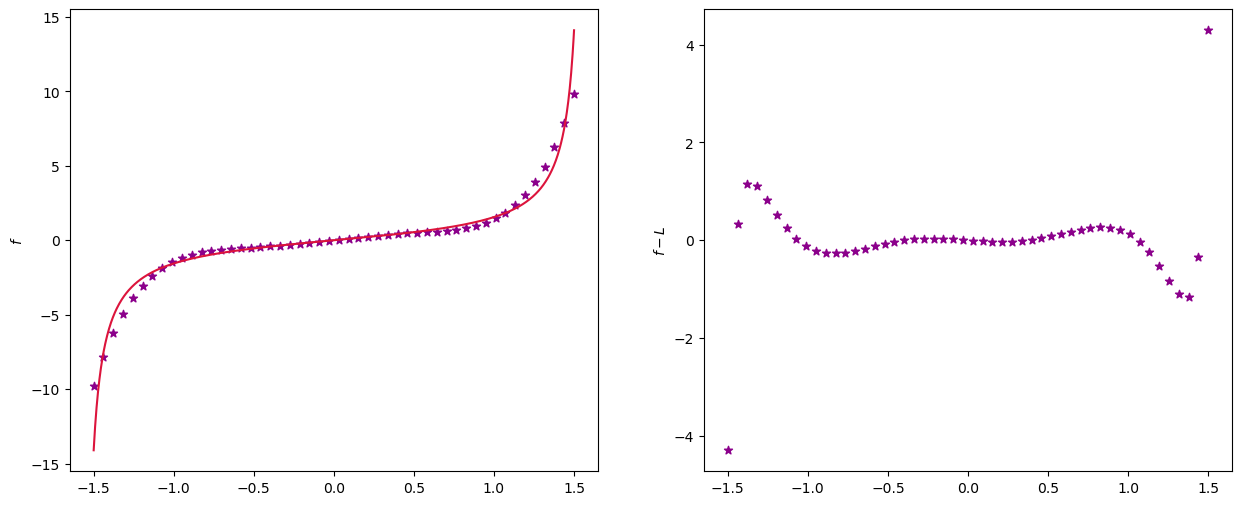

In [10]:
fig1 = plt.figure(figsize=(15, 6))
ax1 = fig1.add_subplot(121)
#ax1.set_title(' ')
#ax1.set_xlabel('V')
ax1.set_ylabel('$f$')
plt.plot(x1, f1, color='crimson')
plt.scatter(unknx1, F1, color='darkmagenta', marker='*')
#plt.plot(big_x_for_graph, big_function_for_graph, color='darkcyan')
ax2 = fig1.add_subplot(122)
#ax1.set_title(' ')
#ax1.set_xlabel('V')
ax2.set_ylabel('$f - L$')
plt.scatter(unknx1, D1, color='darkmagenta', marker='*')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

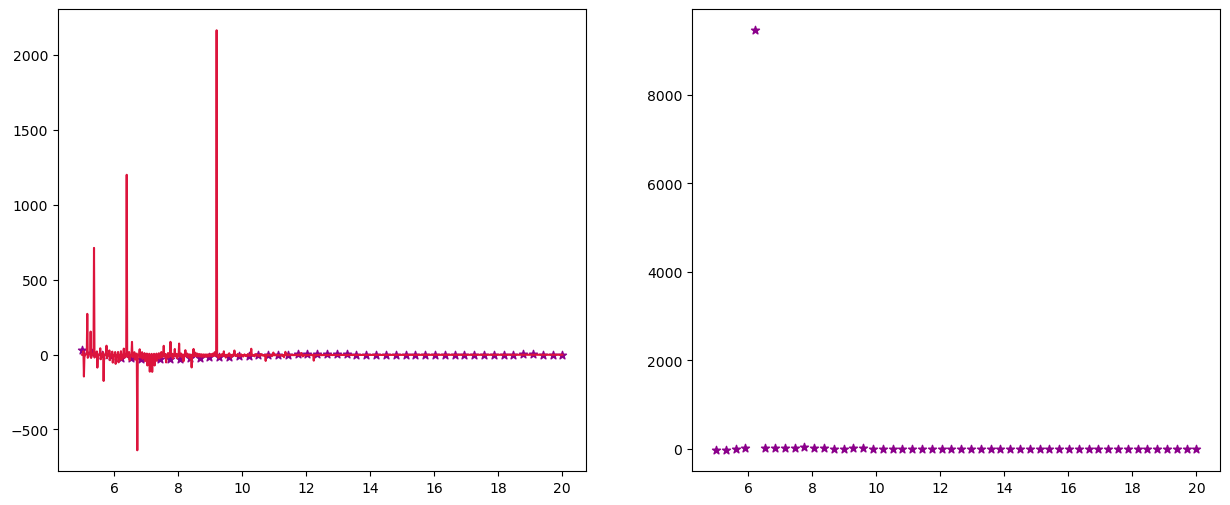

In [12]:
# графики для той самой функции, которые выглядят, как черт знает что

fig1 = plt.figure(figsize=(15, 6))
ax1 = fig1.add_subplot(121)
#ax1.set_title(' ')
#ax1.set_xlabel('V')
#ax1.set_ylabel('$p_i$')
plt.plot(x2, f2, color='crimson')
plt.scatter(unknx2, F2, color='darkmagenta', marker='*')
#plt.plot(big_x_for_graph, big_function_for_graph, color='darkcyan')
ax1 = fig1.add_subplot(122)
#ax1.set_title(' ')
#ax1.set_xlabel('V')
#ax1.set_ylabel('$p_i$')
plt.scatter(unknx2, D2, color='darkmagenta', marker='*')
plt.show